# Assignment 4

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

In [22]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv ("./album_sales.csv")
df.head()


,sales,adverts,airplay,attract
0,330,10.256,43,10
1,120,985.685,28,7
2,360,1445.563,35,7
3,270,1188.193,33,7
4,220,574.513,44,5


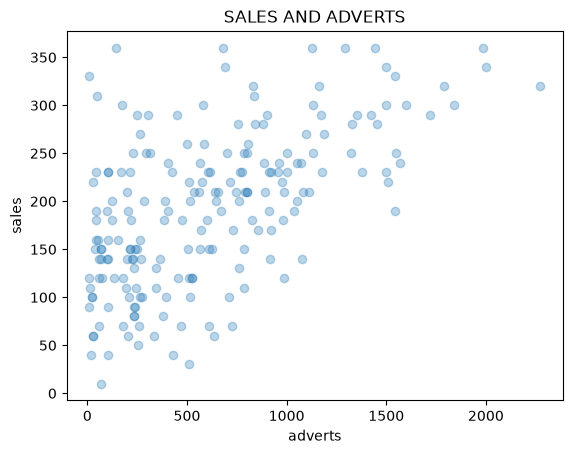

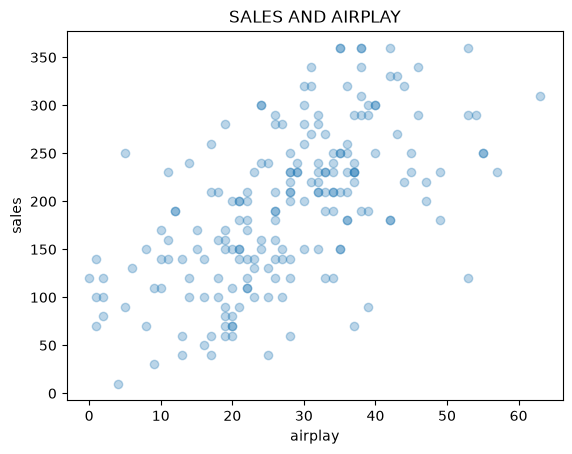

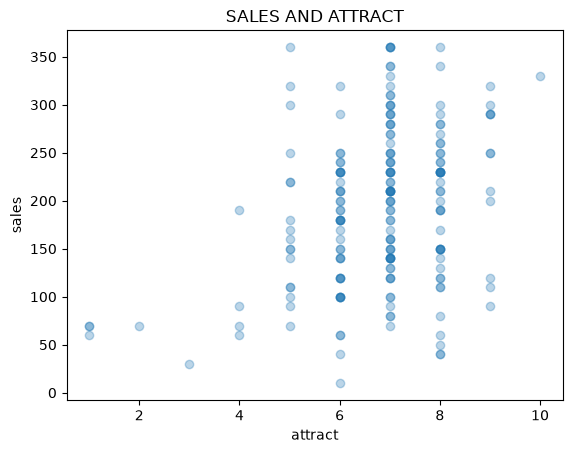

In [7]:
#SALES AND ADVERTS

x = df['adverts']
y = df.sales
x = sm.add_constant(x)  #adds 1 line to get the intercept 

plt.scatter(x['adverts'], y, alpha=0.3)
plt.title("SALES AND ADVERTS")
plt.xlabel('adverts')
plt.ylabel('sales')
plt.show()

#SALES AND AIRPLAY 

x = df["airplay"]
x = sm.add_constant(x)  #adds 1 line to get the intercept 

plt.scatter(x["airplay"], y, alpha=0.3)
plt.title("SALES AND AIRPLAY")
plt.xlabel('airplay')
plt.ylabel('sales')
plt.show()

#SALES AND ATTRACT

x=df['attract']
x = sm.add_constant(x)  #adds 1 line to get the intercept 

plt.scatter(x['attract'], y, alpha=0.3)
plt.title("SALES AND ATTRACT")
plt.xlabel('attract')
plt.ylabel('sales')
plt.show()

In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

With airplay and adverts, there is a positve linear relationship- we can see the data is mostly moving together from bottom left to top right, meaning it is likely that airplay and adverts contribute to sales. Attract, on the other hand, looks a little funky. The data is is not as cluttered as the other ones, but still follows a positive trends overall, meaning attract might constribute to sales. 

### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

                            OLS Regression Results                            
Dep. Variable:                   Prob   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Sat, 19 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        19:49:11   Log-Likelihood:                -1120.7
No. Observations:                 200   AIC:                             2245.
Df Residuals:                     198   BIC:                             2252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        134.1399      7.537     17.799      0.0

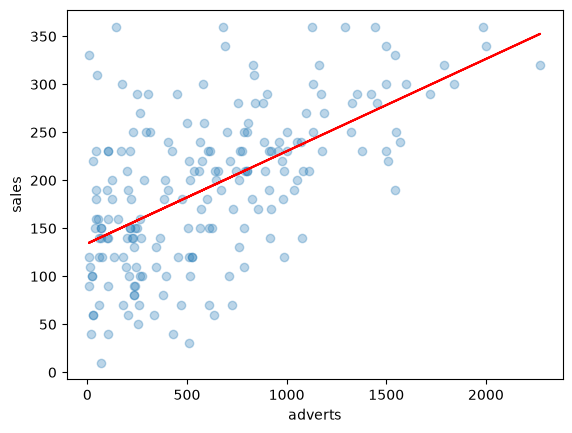

In [11]:
# Code here
x = df['adverts']
y = df.sales
x = sm.add_constant(x)  


model = sm.OLS(y, x).fit()     
predictions = model.predict(x) 
print(model.summary("Prob"))

plt.scatter(x['adverts'], y, alpha=0.3)
plt.xlabel('adverts')
plt.ylabel('sales')
plt.plot(x['adverts'], predictions, color='red')
plt.show()

In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

Our p-value is 2.94e-19; this is extremely small, meaning that it is not likely that we got these results by chance. Thus, there is reason to believe that adverts *does* impact sales.
<br>
The F-statistc is 99.59, meaning it supports what we discovered through the p-value, so there is a great chance that the adverts do influence sales.

### 3. Model Coefficients (10 points)

- Make note of the **intercept** value and **coefficient** (adverts) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [19]:
const   = 134.1399
adverts = 0.0961

total_budget = 135000
x = total_budget/1000
y = round(const + (adverts * x))

print (f"Records sold: {y}")

print()
print (model.params)

Records sold: 147

const      134.139938
adverts      0.096124
dtype: float64


### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [24]:
# Code here
x = df[['adverts', 'airplay', 'attract']]
y = df.sales
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()     
predictions = model.predict(x) 
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Sat, 19 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        20:09:21   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.

Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

Model 2 is the better fit for this data; the R^2 value is 0.665, which is a relatively strong positive correlation. The p value, 2.88e-46, is less than  2.94e-19, the other model's p-value. As the above paragraph mentioned, a higher R^2 value is better if the P value is lower, which is true in this case, making the 2nd model better than the first. This also makes sense from a logical stand point- we saw that adverts and airplay both had a strong positive correlation, which attract had a more or less positive correlation. Combined, it makes sense that these would reflect the data accurately. 

### Submission
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name